<a href="https://colab.research.google.com/github/w4bo/AA2627-unibo-mldm/blob/master/slides/lab-05-association-rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Association rules with Python

We will:

- discretize the Census attributes and mine frequent itemsets;
- reproduce Weka's decreasing-support Apriori search;
- read rule support, antecedent support, confidence, lift, leverage, and conviction;
- constrain rules to a target attribute (Weka's `car` behavior);
- perform Market Basket Analysis at several support and confidence thresholds;
- use lift to interpret the link among hamburger, hamburger buns, and white bread.

In [ ]:
#| echo: false
#| output: false
%pip install mlxtend --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [45]:
#| echo: false
#| output: false

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import arff
from sklearn.metrics import normalized_mutual_info_score
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.spines.top": False, "axes.spines.right": False})


def find_datasets_dir():
    candidates = [Path("datasets"), Path("slides/datasets"), Path.cwd() / "slides" / "datasets"]
    for candidate in candidates:
        if (candidate / "CensusTraining.arff").exists() and (candidate / "MarketBasket.arff").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not find slides/datasets. Start the notebook in the repository root or slides/.")


DATASETS = find_datasets_dir()
DATASETS


PosixPath('/home/slides/datasets')

In [46]:
#| echo: false
#| output: false

def load_arff_frame(filename):
    '''Load a local ARFF file and decode byte-valued nominal columns.'''
    records, metadata = arff.loadarff(DATASETS / filename)
    frame = pd.DataFrame(records)
    for column in frame.columns:
        if frame[column].dtype == object:
            frame[column] = frame[column].map(
                lambda value: value.decode("utf-8") if isinstance(value, bytes) else value
            )
    return frame, metadata


def item_label(itemset):
    '''Stable, readable rendering of a frozenset of items.'''
    return ", ".join(sorted(map(str, itemset)))


def itemset_table(frequent_itemsets, top=None):
    table = frequent_itemsets.copy()
    table["length"] = table["itemsets"].map(len)
    table["itemset"] = table["itemsets"].map(item_label)
    table = table.sort_values(["length", "support"], ascending=[True, False])
    columns = ["length", "support", "itemset"]
    return table[columns].head(top) if top else table[columns]


RULE_COLUMNS = [
    "antecedents", "consequents", "antecedent support", "consequent support",
    "support", "confidence", "lift", "leverage", "conviction"
]


def readable_rules(rules, top=None):
    '''Format mlxtend rules like Weka's antecedent ==> consequent listing.'''
    if rules.empty:
        return pd.DataFrame(columns=["antecedent", "consequent"] + RULE_COLUMNS[2:])
    table = rules[RULE_COLUMNS].copy()
    table["antecedent"] = table.pop("antecedents").map(item_label)
    table["consequent"] = table.pop("consequents").map(item_label)
    table.insert(2, "rule length", rules["antecedents"].map(len) + rules["consequents"].map(len))
    ordered = ["antecedent", "consequent", "rule length"] + RULE_COLUMNS[2:]
    table = table[ordered]
    return table.head(top).round(4) if top else table.round(4)


def mine_rules(binary_frame, min_support, metric="confidence", min_metric=0.9, max_len=None):
    '''Mine itemsets once, then generate and rank rules using Weka-compatible metrics.'''
    itemsets = apriori(binary_frame, min_support=min_support, use_colnames=True, max_len=max_len)
    if itemsets.empty:
        return itemsets, pd.DataFrame(columns=RULE_COLUMNS)
    rules = association_rules(
        itemsets,
        num_itemsets=len(binary_frame),
        metric=metric,
        min_threshold=min_metric,
    )
    if rules.empty:
        return itemsets, rules
    rules = rules.sort_values([metric, "support", "confidence"], ascending=False).reset_index(drop=True)
    return itemsets, rules


def weka_like_search(
    binary_frame,
    lower_bound=0.10,
    upper_bound=1.00,
    delta=0.05,
    metric="confidence",
    min_metric=0.90,
    num_rules=10,
    consequent_prefix=None,
):
    '''Reproduce Weka Apriori's rounds of progressively decreasing support.'''
    support = upper_bound
    history = []
    while support >= lower_bound - 1e-12:
        itemsets, rules = mine_rules(binary_frame, support, metric, min_metric)
        if consequent_prefix is not None and not rules.empty:
            rules = rules[
                (rules["consequents"].map(len) == 1)
                & rules["consequents"].map(
                    lambda values: next(iter(values)).startswith(consequent_prefix)
                )
            ].copy()
            rules = rules.sort_values([metric, "support"], ascending=False).reset_index(drop=True)
        history.append({"min support": support, "itemsets": len(itemsets), "rules": len(rules)})
        if len(rules) >= num_rules or support <= lower_bound + 1e-12:
            break
        support = max(lower_bound, round(support - delta, 10))
    return itemsets, rules.head(num_rules), pd.DataFrame(history)

# Census data

## Dataset overview

The warm-up uses `CensusTraining.arff`, a 1,000-row sample of US census records. Its 15 attributes describe age, employment, education, household role, demographics, capital gains/losses, working hours, country, and whether total income exceeds $50K.

In [47]:
census, census_meta = load_arff_frame("CensusTraining.arff")

print(f"Instances: {len(census):,}")
print(f"Attributes: {census.shape[1]}")


Instances: 1,000
Attributes: 15


## Census sample


In [48]:
census.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


## Census dtypes


In [49]:
census.dtypes.to_frame("dtype")


,dtype
age,float64
workclass,str
fnlwgt,float64
education,str
education-num,float64
marital-status,str
occupation,str
relationship,str
race,str
sex,str


## Census preprocessing

Association-rule search requires discrete attributes. As in the slides, we:

1. discretize every numeric attribute into **10 equal-frequency bins**;
2. remove `fnlwgt` (the final sampling weight);
3. retain one item per observed `attribute=value` pair.

Missing values are not turned into items.

In [50]:
#| echo: false
#| output: false

def discretize_census(frame, bins=10):
    result = frame.drop(columns="fnlwgt").copy()
    for column in result.select_dtypes(include="number"):
        non_missing = result[column].dropna()
        ordered = np.sort(non_missing.to_numpy())
        cut_points = []
        # Weka does not split equal values across bins. At each target rank, move the
        # boundary between that value and the next distinct observed value.
        for k in range(1, bins):
            position = min(int(np.ceil(k * len(ordered) / bins)) - 1, len(ordered) - 1)
            left = ordered[position]
            greater = ordered[ordered > left]
            if len(greater):
                cut_points.append((left + greater[0]) / 2)
        cut_points = sorted(set(cut_points))
        edges = [-np.inf, *cut_points, np.inf]
        result[column] = pd.cut(non_missing, bins=edges).astype("object")
    return result


def encode_attribute_values(frame):
    encoded = {}
    for column in frame.columns:
        values = frame[column]
        for value in sorted(values.dropna().unique(), key=str):
            encoded[f"{column}={value}"] = values.eq(value)
    return pd.DataFrame(encoded, index=frame.index, dtype=bool)


census_discrete = discretize_census(census)
census_items = encode_attribute_values(census_discrete)

print(f"After removing fnlwgt: {census_discrete.shape[1]} attributes")
print(f"One-hot transaction matrix: {census_items.shape[0]} x {census_items.shape[1]}")
census_discrete.head()


After removing fnlwgt: 14 attributes
One-hot transaction matrix: 1000 x 115


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,"(36.5, 41.5]",State-gov,Bachelors,"(11.5, 13.5]",Never-married,Adm-clerical,Not-in-family,White,Male,"(297.0, inf]","(-inf, 326.5]","(35.5, 40.5]",United-States,<=50K
1,"(49.5, 57.5]",Self-emp-not-inc,Bachelors,"(11.5, 13.5]",Married-civ-spouse,Exec-managerial,Husband,White,Male,"(-inf, 297.0]","(-inf, 326.5]","(-inf, 24.5]",United-States,<=50K
2,"(36.5, 41.5]",Private,HS-grad,"(7.5, 9.5]",Divorced,Handlers-cleaners,Not-in-family,White,Male,"(-inf, 297.0]","(-inf, 326.5]","(35.5, 40.5]",United-States,<=50K
3,"(49.5, 57.5]",Private,11th,"(-inf, 7.5]",Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,"(-inf, 297.0]","(-inf, 326.5]","(35.5, 40.5]",United-States,<=50K
4,"(25.5, 29.5]",Private,Bachelors,"(11.5, 13.5]",Married-civ-spouse,Prof-specialty,Wife,Black,Female,"(-inf, 297.0]","(-inf, 326.5]","(35.5, 40.5]",Cuba,<=50K


## Manual correlation check

In association analysis there is no privileged class unless we deliberately choose one. A pairwise check reveals the strongest expected relationship: `education` and `education-num` encode nearly the same concept. Normalized mutual information (NMI) is 0 for independence and 1 for a deterministic correspondence.

In [51]:
education_pairs = census[["education", "education-num"]].dropna()
education_nmi = normalized_mutual_info_score(
    education_pairs["education"].astype(str), education_pairs["education-num"].astype(str)
)

print(f"NMI(education, education-num) = {education_nmi:.3f}")
pd.crosstab(education_pairs["education"], education_pairs["education-num"])


NMI(education, education-num) = 1.000


education-num,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0
education,,,,,,,,,,,,,,,,
10th,0,0,0,0,0,21,0,0,0,0,0,0,0,0,0,0
11th,0,0,0,0,0,0,46,0,0,0,0,0,0,0,0,0
12th,0,0,0,0,0,0,0,9,0,0,0,0,0,0,0,0
1st-4th,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5th-6th,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,0
7th-8th,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0
9th,0,0,0,0,16,0,0,0,0,0,0,0,0,0,0,0
Assoc-acdm,0,0,0,0,0,0,0,0,0,0,0,35,0,0,0,0
Assoc-voc,0,0,0,0,0,0,0,0,0,0,48,0,0,0,0,0


# Apriori

Allowed metrics include confidence, lift, leverage, and conviction. Rules are ordered by the selected metric. For a rule $A \Rightarrow B$:

- **antecedent support** is $s(A)$;
- **consequent support** is $s(B)$;
- **rule support** is $s(A \cup B)$;
- **confidence** is $s(A \cup B) / s(A)$;
- **lift** is $s(A \cup B) / (s(A)s(B))$.

Because support is anti-monotone, $s(A \cup B) \leq s(A)$ and $s(A \cup B) \leq s(B)$.

## Default search with decreasing support

Start at the upper support bound, decrease it by `delta`, and stop once ten confidence-qualified rules are available.

In [52]:
census_itemsets_10, census_rules_10, census_history_10 = weka_like_search(
    census_items,
    lower_bound=0.10,
    upper_bound=1.00,
    delta=0.05,
    metric="confidence",
    min_metric=0.90,
    num_rules=10,
)



## Census decreasing-support rounds


In [53]:
census_history_10


,min support,itemsets,rules
0,1.00,0,0
1,0.95,1,0
2,0.90,3,0
3,0.85,5,4
4,0.80,8,6
5,0.75,12,11


## Census frequent itemsets at the stopping round


In [54]:
itemset_table(census_itemsets_10)


,length,support,itemset
2,1,0.950,"capital-loss=(-inf, 326.5]"
1,1,0.919,"capital-gain=(-inf, 297.0]"
3,1,0.902,native-country=United-States
0,1,0.847,race=White
4,1,0.768,class=<=50K
8,2,0.869,"capital-gain=(-inf, 297.0], capital-loss=(-inf, 326.5]"
10,2,0.861,"capital-loss=(-inf, 326.5], native-country=United-States"
9,2,0.826,"capital-gain=(-inf, 297.0], native-country=United-States"
6,2,0.805,"capital-loss=(-inf, 326.5], race=White"
7,2,0.778,"native-country=United-States, race=White"


## Census best rules


In [55]:
readable_rules(census_rules_10)


,antecedent,consequent,rule length,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,native-country=United-States,"capital-loss=(-inf, 326.5]",2,0.902,0.950,0.861,0.9545,1.0048,0.0041,1.1000
1,race=White,"capital-loss=(-inf, 326.5]",2,0.847,0.950,0.805,0.9504,1.0004,0.0004,1.0083
2,"capital-gain=(-inf, 297.0], native-country=United-States","capital-loss=(-inf, 326.5]",3,0.826,0.950,0.785,0.9504,1.0004,0.0003,1.0073
3,"capital-gain=(-inf, 297.0]","capital-loss=(-inf, 326.5]",2,0.919,0.950,0.869,0.9456,0.9954,-0.0040,0.9190
4,race=White,native-country=United-States,2,0.847,0.902,0.778,0.9185,1.0183,0.0140,1.2030
5,native-country=United-States,"capital-gain=(-inf, 297.0]",2,0.902,0.919,0.826,0.9157,0.9965,-0.0029,0.9613
6,"capital-loss=(-inf, 326.5]","capital-gain=(-inf, 297.0]",2,0.950,0.919,0.869,0.9147,0.9954,-0.0040,0.9500
7,race=White,"capital-gain=(-inf, 297.0]",2,0.847,0.919,0.774,0.9138,0.9944,-0.0044,0.9398
8,"capital-loss=(-inf, 326.5], native-country=United-States","capital-gain=(-inf, 297.0]",3,0.861,0.919,0.785,0.9117,0.9921,-0.0063,0.9176
9,"capital-loss=(-inf, 326.5]",native-country=United-States,2,0.950,0.902,0.861,0.9063,1.0048,0.0041,1.0461


## Reading antecedent and rule support

The rule support must never exceed either side's support; the check below verifies the anti-monotone relationship numerically.

In [ ]:
if not census_rules_10.empty:
    check = census_rules_10.assign(
        anti_monotone_ok=lambda x: (x["support"] <= x["antecedent support"]) & (x["support"] <= x["consequent support"])
    )[["antecedent support", "consequent support", "support", "anti_monotone_ok"]]
    assert check["anti_monotone_ok"].all()

check.round(4) if not census_rules_10.empty else pd.DataFrame()


,antecedent support,consequent support,support,anti_monotone_ok
0,0.902,0.950,0.861,True
1,0.847,0.950,0.805,True
2,0.826,0.950,0.785,True
3,0.919,0.950,0.869,True
4,0.847,0.902,0.778,True
5,0.902,0.919,0.826,True
6,0.950,0.919,0.869,True
7,0.847,0.919,0.774,True
8,0.861,0.919,0.785,True
9,0.950,0.902,0.861,True


## Iterative search with decreasing support

Start at the upper support bound and lowers it by `delta`. Each round returns rules above `minMetric`; the cycle stops when it reaches the lower bound or has found `numRules` rules. Increasing `numRules` therefore permits more rounds and can reveal lower-support but higher-confidence rules.

In [57]:
census_itemsets_100, census_rules_100, census_history_100 = weka_like_search(
    census_items,
    lower_bound=0.10,
    upper_bound=1.00,
    delta=0.05,
    metric="confidence",
    min_metric=0.90,
    num_rules=100,
)

print(f"Stopping support: {census_history_100.iloc[-1]['min support']:.2f}")
print(f"Rules returned: {len(census_rules_100)}")


Stopping support: 0.45
Rules returned: 100


## Census broad rule search history


In [58]:
census_history_100


,min support,itemsets,rules
0,1.00,0,0
1,0.95,1,0
2,0.90,3,0
3,0.85,5,4
4,0.80,8,6
5,0.75,12,11
6,0.70,18,22
7,0.65,25,30
8,0.60,35,42
9,0.55,48,59


## Census broad rule search results


In [83]:
readable_rules(census_rules_100, top=10)


,antecedent,consequent,rule length,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,"class=<=50K, race=White","capital-loss=(-inf, 326.5]",3,0.640,0.95,0.619,0.9672,1.0181,0.0110,1.5238
1,"class=<=50K, native-country=United-States","capital-loss=(-inf, 326.5]",3,0.693,0.95,0.670,0.9668,1.0177,0.0117,1.5065
2,"class=<=50K, native-country=United-States, race=White","capital-loss=(-inf, 326.5]",4,0.584,0.95,0.564,0.9658,1.0166,0.0092,1.4600
3,"capital-gain=(-inf, 297.0], class=<=50K, race=White","capital-loss=(-inf, 326.5]",4,0.610,0.95,0.589,0.9656,1.0164,0.0095,1.4524
4,"capital-gain=(-inf, 297.0], class=<=50K, native-country=United-States","capital-loss=(-inf, 326.5]",4,0.658,0.95,0.635,0.9650,1.0158,0.0099,1.4304
5,"capital-gain=(-inf, 297.0], class=<=50K, native-country=United-States, race=White","capital-loss=(-inf, 326.5]",5,0.554,0.95,0.534,0.9639,1.0146,0.0077,1.3850
6,class=<=50K,"capital-loss=(-inf, 326.5]",2,0.768,0.95,0.740,0.9635,1.0143,0.0104,1.3714
7,"capital-gain=(-inf, 297.0], class=<=50K","capital-loss=(-inf, 326.5]",3,0.732,0.95,0.704,0.9617,1.0124,0.0086,1.3071
8,"class=<=50K, native-country=United-States, workclass=Private","capital-loss=(-inf, 326.5]",4,0.486,0.95,0.467,0.9609,1.0115,0.0053,1.2789
9,"class=<=50K, sex=Male","capital-loss=(-inf, 326.5]",3,0.480,0.95,0.461,0.9604,1.0110,0.0050,1.2632


## Interpreting the broad rule search

The first returned rules maximize confidence, even when their support is lower. Limiting the support interval is useful when we want patterns at a particular prevalence and want to avoid rules driven only by extremely common single attributes.

## Calibrating support for longer rules

<details>
<summary>Suggested answer</summary>

A lower support near **0.70** is a useful reference point. At that level, only very frequent items survive, so the remaining three-item sets generate several different rules while longer, rarer combinations disappear.
</details>

In [60]:
census_itemsets_70, census_rules_70 = mine_rules(
    census_items, min_support=0.70, metric="confidence", min_metric=0.90
)

length_summary_70 = (
    census_itemsets_70.assign(length=census_itemsets_70["itemsets"].map(len))
    .groupby("length").size().rename("frequent itemsets").to_frame()
)
print(f"Frequent itemsets: {len(census_itemsets_70)}")
print(f"Rules generated: {len(census_rules_70)}")


Frequent itemsets: 18
Rules generated: 22


## Census high-support itemset lengths


In [61]:
length_summary_70


,frequent itemsets
length,
1,5
2,8
3,5


## Census high-support rules


In [62]:
readable_rules(census_rules_70)


,antecedent,consequent,rule length,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,class=<=50K,"capital-loss=(-inf, 326.5]",2,0.768,0.950,0.740,0.9635,1.0143,0.0104,1.3714
1,"capital-gain=(-inf, 297.0], class=<=50K","capital-loss=(-inf, 326.5]",3,0.732,0.950,0.704,0.9617,1.0124,0.0086,1.3071
2,native-country=United-States,"capital-loss=(-inf, 326.5]",2,0.902,0.950,0.861,0.9545,1.0048,0.0041,1.1000
3,class=<=50K,"capital-gain=(-inf, 297.0]",2,0.768,0.919,0.732,0.9531,1.0371,0.0262,1.7280
4,"capital-loss=(-inf, 326.5], class=<=50K","capital-gain=(-inf, 297.0]",3,0.740,0.919,0.704,0.9514,1.0352,0.0239,1.6650
5,"native-country=United-States, race=White","capital-loss=(-inf, 326.5]",3,0.778,0.950,0.740,0.9512,1.0012,0.0009,1.0237
6,race=White,"capital-loss=(-inf, 326.5]",2,0.847,0.950,0.805,0.9504,1.0004,0.0004,1.0083
7,"capital-gain=(-inf, 297.0], native-country=United-States","capital-loss=(-inf, 326.5]",3,0.826,0.950,0.785,0.9504,1.0004,0.0003,1.0073
8,"capital-gain=(-inf, 297.0], race=White","capital-loss=(-inf, 326.5]",3,0.774,0.950,0.732,0.9457,0.9955,-0.0033,0.9214
9,"capital-gain=(-inf, 297.0]","capital-loss=(-inf, 326.5]",2,0.919,0.950,0.869,0.9456,0.9954,-0.0040,0.9190


## Why rules can outnumber itemsets

Each frequent itemset can produce multiple antecedent/consequent partitions, which is why the number of rules may exceed the number of itemsets. At a high support bound, the search can also stop because no further itemsets satisfy both the support and confidence thresholds.

## Rules for a target attribute (`car=True`)

Weka's `car=True` constrains the chosen class attribute to the consequent. Here the original class (attribute 15 in Python's one-based counting; Weka may show a zero-based index) is represented by items beginning with `class=`.

In [63]:
car_itemsets, car_rules, car_history = weka_like_search(
    census_items,
    lower_bound=0.10,
    upper_bound=1.00,
    delta=0.05,
    metric="confidence",
    min_metric=0.90,
    num_rules=20,
    consequent_prefix="class=",
)



## Census class-consequent search history


In [64]:
car_history


,min support,itemsets,rules
0,1.00,0,0
1,0.95,1,0
2,0.90,3,0
3,0.85,5,0
4,0.80,8,0
5,0.75,12,0
6,0.70,18,0
7,0.65,25,0
8,0.60,35,0
9,0.55,48,0


## Census class-consequent rules


In [65]:
readable_rules(car_rules)


,antecedent,consequent,rule length,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,"capital-gain=(-inf, 297.0], capital-loss=(-inf, 326.5], marital-status=Never-married, native-country=United-States, ...",class=<=50K,6,0.249,0.768,0.240,0.9639,1.2550,0.0488,6.4187
1,"capital-gain=(-inf, 297.0], capital-loss=(-inf, 326.5], marital-status=Never-married, native-country=United-States",class=<=50K,5,0.292,0.768,0.281,0.9623,1.2530,0.0567,6.1585
2,"capital-gain=(-inf, 297.0], capital-loss=(-inf, 326.5], marital-status=Never-married, race=White",class=<=50K,5,0.264,0.768,0.254,0.9621,1.2528,0.0512,6.1248
3,"capital-gain=(-inf, 297.0], capital-loss=(-inf, 326.5], marital-status=Never-married",class=<=50K,4,0.313,0.768,0.301,0.9617,1.2522,0.0606,6.0513
4,"capital-gain=(-inf, 297.0], marital-status=Never-married, native-country=United-States, race=White",class=<=50K,5,0.259,0.768,0.249,0.9614,1.2518,0.0501,6.0088
5,"capital-gain=(-inf, 297.0], marital-status=Never-married, native-country=United-States",class=<=50K,4,0.304,0.768,0.292,0.9605,1.2507,0.0585,5.8773
6,"capital-gain=(-inf, 297.0], marital-status=Never-married",class=<=50K,3,0.326,0.768,0.313,0.9601,1.2502,0.0626,5.8178
7,"capital-gain=(-inf, 297.0], marital-status=Never-married, race=White",class=<=50K,4,0.274,0.768,0.263,0.9599,1.2498,0.0526,5.7789
8,"capital-gain=(-inf, 297.0], capital-loss=(-inf, 326.5], marital-status=Never-married, race=White, workclass=Private",class=<=50K,6,0.211,0.768,0.202,0.9573,1.2465,0.0400,5.4391
9,"capital-gain=(-inf, 297.0], capital-loss=(-inf, 326.5], marital-status=Never-married, native-country=United-States, ...",class=<=50K,6,0.233,0.768,0.223,0.9571,1.2462,0.0441,5.4056


## Census class-consequent rule counts


In [66]:
car_rules["consequents"].map(item_label).value_counts().to_frame("rules") if not car_rules.empty else pd.DataFrame()


,rules
consequents,
class=<=50K,20


## Interpreting class-association rules

All returned rules have income class as the consequent. The dominant consequent is `class=<=50K`, because that is by far the more frequent class in this sample. Weka-style CAR search constrains the *attribute*, not a specific value; filtering to one value is an additional step:

In [67]:
target_over_50k = car_rules[
    car_rules["consequents"].map(lambda values: "class=>50K" in values)
]
readable_rules(target_over_50k)


,antecedent,consequent,antecedent support,consequent support,support,confidence,lift,leverage,conviction


# Market Basket Analysis

## Dataset overview

Market Basket Analysis identifies buying habits that can inform promotions, shelf placement, and advertising. `MarketBasket.arff` contains 651 transactions and 56 binary product attributes.

The local file uses Weka's dense asymmetric encoding: `t` means purchased, while `f` or `?` means absent. Treating absence as a regular item would produce unhelpful rules about products *not* being bought, so only `t` becomes `True` in the transaction matrix.

In [ ]:
market_raw, market_meta = load_arff_frame("MarketBasket.arff")
market_raw.columns = market_raw.columns.str.strip()
market = market_raw.eq("t").astype(bool)

print(f"Instances: {len(market):,}, Products: {market.shape[1]}, Average products per transaction: {market.sum(axis=1).mean():.2f}")
market.head()


Instances: 651
Products: 56
Average products per transaction: 4.79


,Lemons,Standard coffee,Frozen Chicken Wings,98pct. Fat Free Hamburger,Sugar Cookies,Onions,Vanilla Ice Cream,Potato Chips,Cheese Crackers,Chocolate Bar,...,Chicken Legs,Regular Coffee,Cookies,Aspirin,Sweet Potatoes,Strawberry Waffles,Green Beans,Imported Beer,Small Eggs,Silver Cleaner
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


## Threshold experiments

We reproduce the threshold experiments from the reference:

1. default-like settings: support 0.10, 10 rules, confidence 0.90;
2. support 0.01, confidence 0.90;
3. support 0.05, confidence 0.90;
4. support 0.05, confidence 0.70.

In [69]:
#| echo: false

market_experiments = []
market_results = {}

for min_support, min_confidence in [(0.10, 0.90), (0.01, 0.90), (0.05, 0.90), (0.05, 0.70)]:
    itemsets, rules = mine_rules(
        market, min_support=min_support, metric="confidence", min_metric=min_confidence
    )
    key = (min_support, min_confidence)
    market_results[key] = (itemsets, rules)
    market_experiments.append({
        "min support": min_support,
        "min confidence": min_confidence,
        "frequent itemsets": len(itemsets),
        "maximum itemset length": int(itemsets["itemsets"].map(len).max()) if len(itemsets) else 0,
        "rules": len(rules),
    })

market_experiments = pd.DataFrame(market_experiments)
market_experiments


,min support,min confidence,frequent itemsets,maximum itemset length,rules
0,0.10,0.9,23,2,0
1,0.01,0.9,30381,9,33114
2,0.05,0.9,163,4,0
3,0.05,0.7,163,4,41


## Rules returned by each threshold

Compare the highest-ranked rules after changing minimum support and minimum confidence.

## Market rules with default thresholds


In [70]:
itemsets, rules = market_results[(0.10, 0.90)]
print("No association rules found." if rules.empty else f"Rules: {len(rules)}")
readable_rules(rules, top=10) if not rules.empty else pd.DataFrame()


No association rules found.


""


## Market rules with lower support


In [71]:
itemsets, rules = market_results[(0.01, 0.90)]
print("No association rules found." if rules.empty else f"Rules: {len(rules)}")
readable_rules(rules, top=10) if not rules.empty else pd.DataFrame()


Rules: 33114


,antecedent,consequent,rule length,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,"2pct. Milk, 98pct. Fat Free Hamburger, Eggs, Onions",Potato Chips,5,0.0323,0.2043,0.0323,1.0,4.8947,0.0257,inf
1,"2pct. Milk, 98pct. Fat Free Hamburger, Apples, Eggs",Potato Chips,5,0.0307,0.2043,0.0307,1.0,4.8947,0.0244,inf
2,"2pct. Milk, 98pct. Fat Free Hamburger, Apples, Potato Chips",Eggs,5,0.0307,0.2565,0.0307,1.0,3.8982,0.0228,inf
3,"Apples, Onions, Potato Chips",2pct. Milk,4,0.0292,0.2289,0.0292,1.0,4.3691,0.0225,inf
4,"Apples, Eggs, Onions",2pct. Milk,4,0.0292,0.2289,0.0292,1.0,4.3691,0.0225,inf
5,"Frozen Carrots, Potato Chips",White Bread,3,0.0276,0.2488,0.0276,1.0,4.0185,0.0208,inf
6,"Cola, Sugar Cookies, Tomatoes",Eggs,4,0.0276,0.2565,0.0276,1.0,3.8982,0.0206,inf
7,"Sugar Cookies, Sweet Relish, Tomatoes",Eggs,4,0.0276,0.2565,0.0276,1.0,3.8982,0.0206,inf
8,"Cola, Sugar Cookies, Tomatoes",White Bread,4,0.0276,0.2488,0.0276,1.0,4.0185,0.0208,inf
9,"Cola, Sugar Cookies, Tomatoes, White Bread",Eggs,5,0.0276,0.2565,0.0276,1.0,3.8982,0.0206,inf


## Market rules with moderate support


In [72]:
itemsets, rules = market_results[(0.05, 0.90)]
print("No association rules found." if rules.empty else f"Rules: {len(rules)}")
readable_rules(rules, top=10) if not rules.empty else pd.DataFrame()


No association rules found.


""


## Market rules with lower confidence


In [73]:
itemsets, rules = market_results[(0.05, 0.70)]
print("No association rules found." if rules.empty else f"Rules: {len(rules)}")
readable_rules(rules, top=10) if not rules.empty else pd.DataFrame()


Rules: 41


,antecedent,consequent,rule length,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,"2pct. Milk, Cola, Eggs",White Bread,4,0.0614,0.2488,0.0507,0.8250,3.3153,0.0354,4.2923
1,"Cola, Eggs, White Bread",2pct. Milk,4,0.0630,0.2289,0.0507,0.8049,3.5166,0.0363,3.9520
2,"2pct. Milk, Cola, White Bread",Eggs,4,0.0630,0.2565,0.0507,0.8049,3.1376,0.0345,3.8103
3,"2pct. Milk, Potato Chips, White Bread",Eggs,4,0.0691,0.2565,0.0553,0.8000,3.1186,0.0376,3.7174
4,"Potato Chips, Tomatoes",White Bread,3,0.0676,0.2488,0.0538,0.7955,3.1965,0.0369,3.6723
5,"2pct. Milk, Tomatoes",Eggs,3,0.0676,0.2565,0.0538,0.7955,3.1008,0.0364,3.6347
6,"2pct. Milk, Tomatoes",White Bread,3,0.0676,0.2488,0.0538,0.7955,3.1965,0.0369,3.6723
7,"2pct. Milk, Aspirin",White Bread,3,0.0722,0.2488,0.0568,0.7872,3.1635,0.0389,3.5304
8,"Eggs, Potato Chips, White Bread",2pct. Milk,4,0.0707,0.2289,0.0553,0.7826,3.4193,0.0391,3.5472
9,"2pct. Milk, Eggs, Potato Chips",White Bread,4,0.0707,0.2488,0.0553,0.7826,3.1449,0.0377,3.4553


## Interpreting the threshold experiments

At support 0.10 the frequent-itemset collection is short and no rule reaches 0.90 confidence. Lowering support to 0.01 admits long, rare combinations; their small antecedent counts make confidence 1 possible by chance. At support 0.05, confidence 0.90 is still too strict. Reducing confidence to 0.70 yields shorter, better-supported rules, but confidence alone still favors very common consequent products.

## Why confidence can be misleading

Frequently purchased staples can appear in high-confidence rules even without a strong association. The reference highlights 2% milk, eggs, cola, and white bread.

In [ ]:
staples = ["2pct. Milk", "Eggs", "Cola", "White Bread"]
staple_support = market[staples].mean().sort_values(ascending=False).to_frame("support")
staple_support.round(3)


## Market staple support chart


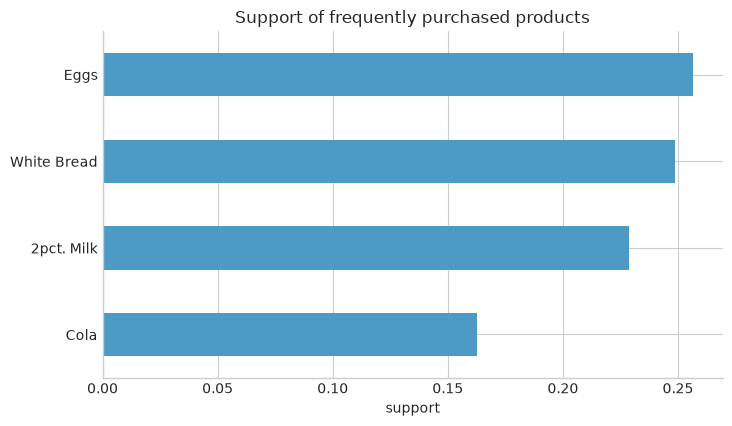

In [76]:
ax = staple_support.sort_values("support").plot.barh(legend=False, color="#4C9BC6")
ax.set(xlabel="support", ylabel="", title="Support of frequently purchased products")
plt.show()


## From frequent staples to target rules

These products are bought often regardless of other items. Rare combinations can therefore imply a staple with high confidence while having very low support. Raising support removes many accidental combinations, but we then need to accept lower confidence and shorter patterns.

## Rules with a specific consequent: Eggs

To imitate a target-item search, retain only rules whose consequent is exactly `Eggs`. The high-confidence rules are based on small joint counts, confirming that eggs are frequent but not tightly linked to one particular basket.

In [77]:
market_itemsets_01, market_rules_01 = market_results[(0.01, 0.90)]
egg_rules = market_rules_01[
    market_rules_01["consequents"].map(lambda values: values == frozenset({"Eggs"}))
].copy()

readable_rules(egg_rules, top=15)


,antecedent,consequent,rule length,antecedent support,consequent support,support,confidence,lift,leverage,conviction
2,"2pct. Milk, 98pct. Fat Free Hamburger, Apples, Potato Chips",Eggs,5,0.0307,0.2565,0.0307,1.0,3.8982,0.0228,inf
6,"Cola, Sugar Cookies, Tomatoes",Eggs,4,0.0276,0.2565,0.0276,1.0,3.8982,0.0206,inf
7,"Sugar Cookies, Sweet Relish, Tomatoes",Eggs,4,0.0276,0.2565,0.0276,1.0,3.8982,0.0206,inf
9,"Cola, Sugar Cookies, Tomatoes, White Bread",Eggs,5,0.0276,0.2565,0.0276,1.0,3.8982,0.0206,inf
12,"Cookies, Potato Chips",Eggs,3,0.0261,0.2565,0.0261,1.0,3.8982,0.0194,inf
13,"Aspirin, Sugar Cookies, Tomatoes",Eggs,4,0.0261,0.2565,0.0261,1.0,3.8982,0.0194,inf
20,"2pct. Milk, 98pct. Fat Free Hamburger, Apples, Potato Chips, White Bread",Eggs,6,0.0261,0.2565,0.0261,1.0,3.8982,0.0194,inf
24,"Sugar Cookies, Sweet Relish, Tomatoes, White Bread",Eggs,5,0.0246,0.2565,0.0246,1.0,3.8982,0.0183,inf
25,"Aspirin, Sugar Cookies, Tomatoes, White Bread",Eggs,5,0.0246,0.2565,0.0246,1.0,3.8982,0.0183,inf
28,"2pct. Milk, Potato Chips, Sweet Relish, Tomatoes",Eggs,5,0.0246,0.2565,0.0246,1.0,3.8982,0.0183,inf


# Lift: revealing correlation

Confidence $P(B\mid A)$ does not correct for how common $B$ already is. Lift does:

$$
\operatorname{lift}(A \Rightarrow B) = \frac{P(A \cap B)}{P(A)P(B)}
$$

- lift $>1$: positive association;
- lift $=1$: independence;
- lift $<1$: negative association.

Using support 0.10 keeps the comparison focused on well-supported product pairs.

## Market items lift

In [ ]:
market_itemsets_lift, market_rules_lift = mine_rules(market, min_support=0.10, metric="lift", min_metric=1.0)
readable_rules(market_rules_lift, top=15)


,antecedent,consequent,rule length,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Hamburger Buns,98pct. Fat Free Hamburger,2,0.1490,0.1951,0.1014,0.6804,3.4878,0.0723,2.5186
1,98pct. Fat Free Hamburger,Hamburger Buns,2,0.1951,0.1490,0.1014,0.5197,3.4878,0.0723,1.7718
2,White Bread,98pct. Fat Free Hamburger,2,0.2488,0.1951,0.1029,0.4136,2.1200,0.0544,1.3726
3,98pct. Fat Free Hamburger,White Bread,2,0.1951,0.2488,0.1029,0.5276,2.1200,0.0544,1.5899
4,Potato Chips,White Bread,2,0.2043,0.2488,0.1075,0.5263,2.1150,0.0567,1.5858
5,White Bread,Potato Chips,2,0.2488,0.2043,0.1075,0.4321,2.1150,0.0567,1.4011
6,Eggs,Potato Chips,2,0.2565,0.2043,0.1014,0.3952,1.9344,0.0490,1.3157
7,Potato Chips,Eggs,2,0.2043,0.2565,0.1014,0.4962,1.9344,0.0490,1.4758
8,2pct. Milk,White Bread,2,0.2289,0.2488,0.1075,0.4698,1.8879,0.0506,1.4167
9,White Bread,2pct. Milk,2,0.2488,0.2289,0.1075,0.4321,1.8879,0.0506,1.3578


## Hamburger buns, fat-free hamburger, and white bread

The strongest lifted pair is `98pct. Fat Free Hamburger` with `Hamburger Buns`; fat-free hamburger is also positively associated with `White Bread`. We now inspect the exact counts, including the three-way overlap that is hidden by pairwise rules.

In [ ]:
hamburger = "98pct. Fat Free Hamburger"
buns = "Hamburger Buns"
bread = "White Bread"

counts = pd.Series({
    "Hamburger": int(market[hamburger].sum()),
    "Buns": int(market[buns].sum()),
    "White bread": int(market[bread].sum()),
    "Hamburger and buns": int((market[hamburger] & market[buns]).sum()),
    "Hamburger and white bread": int((market[hamburger] & market[bread]).sum()),
    "Hamburger, buns, and white bread": int((market[hamburger] & market[buns] & market[bread]).sum()),
}, name="transactions").to_frame()


## Hamburger bun and bread choices


In [81]:
hamburger_baskets = market.loc[market[hamburger], [buns, bread]]
choice_table = (
    hamburger_baskets.value_counts()
    .rename("transactions")
    .rename_axis(["buys buns", "buys white bread"])
    .to_frame()
)
choice_table


transactions
buys buns buys white bread              
True      True                        36
False     True                        31
          False                       30
True      False                       30

## Pairwise lift rules for the three products

Filter the lifted rules to the hamburger, buns, and white-bread subset before interpreting the relationship.

In [82]:
focus_rules = market_rules_lift[
    market_rules_lift["antecedents"].map(lambda s: s.issubset({hamburger, buns, bread}))
    & market_rules_lift["consequents"].map(lambda s: s.issubset({hamburger, buns, bread}))
]
readable_rules(focus_rules)


,antecedent,consequent,rule length,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,Hamburger Buns,98pct. Fat Free Hamburger,2,0.1490,0.1951,0.1014,0.6804,3.4878,0.0723,2.5186
1,98pct. Fat Free Hamburger,Hamburger Buns,2,0.1951,0.1490,0.1014,0.5197,3.4878,0.0723,1.7718
2,White Bread,98pct. Fat Free Hamburger,2,0.2488,0.1951,0.1029,0.4136,2.1200,0.0544,1.3726
3,98pct. Fat Free Hamburger,White Bread,2,0.1951,0.2488,0.1029,0.5276,2.1200,0.0544,1.5899


## Hamburger basket interpretation

<details>
<summary>Suggested answer</summary>

Buyers of the fat-free hamburger often pair it with either white bread or hamburger buns, and both pairwise associations have lift well above one. The three-way combination has support only $36/651 \approx 0.055$, so it is absent from the itemsets at the chosen support threshold. This supports the slide's interpretation of the two bread products as alternatives at that threshold, but the direct count also shows that they are **not literally mutually exclusive**. Pairwise rules alone cannot establish exclusivity.
</details>

# Takeaways

- Apriori exploits the anti-monotone property of support to prune itemsets.
- Weka's decreasing-support loop can be reproduced by repeated `mlxtend` Apriori calls.
- High confidence is not automatically interesting when the consequent is already common.
- Support controls prevalence; confidence controls conditional reliability; lift measures departure from independence.
- Target-consequent filtering reproduces class association rules, but specifying one target value requires an extra filter.
- Inspect the original counts before turning pairwise rules into a business conclusion.